In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
import os
import random

B = low
mono = high


In [3]:
low_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/b_Class_genomap.npy')
low_data.shape

(1186, 40, 40, 1)

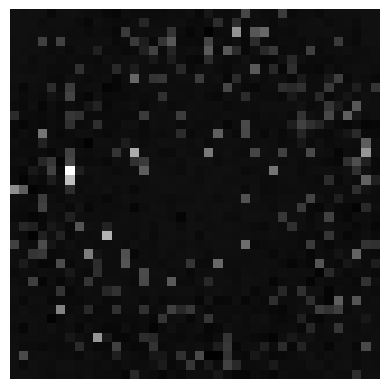

In [ ]:
image = low_data[777]
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

In [4]:
high_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/mono_Class_genomap.npy')
high_data.shape

(1186, 40, 40, 1)

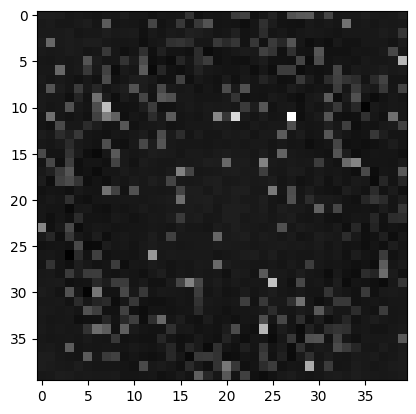

In [ ]:
image = high_data[10]
plt.imshow(image, cmap='gray')
plt.show()

In [5]:
y = [0] * low_data.shape[0] +  [1] * high_data.shape[0]

In [6]:
data = np.vstack([low_data, high_data ])

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(data, y, test_size=0.20, random_state=42)

In [ ]:
trian_ds = tf.data.Dataset.from_tensor_slices((X_train , y_train ))
trian_ds = trian_ds.shuffle(buffer_size=1000)
trian_ds = trian_ds.batch(32)

In [ ]:
test_ds = tf.data.Dataset.from_tensor_slices((X_test , y_test ))
test_ds = test_ds.batch(32)

In [ ]:
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(40, 40, 1)),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), padding='same' ,activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.4),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [ ]:
model = create_model()
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)                    │ (None, 40, 40, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 20, 20, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 20, 20, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 10, 10, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 5, 5, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 2, 2, 128)           │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │          65,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 453,633 (1.73 MB)

 Trainable params: 453,633 (1.73 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5 ,  restore_best_weights=True)

In [ ]:
history = model.fit(trian_ds,
                    epochs=1000,
                    validation_data=test_ds,
                    callbacks=[early_stopping])

Epoch 1/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 13s 160ms/step - accuracy: 0.5512 - loss: 0.6860 - val_accuracy: 0.8526 - val_loss: 0.5880
Epoch 2/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 148ms/step - accuracy: 0.8545 - loss: 0.4990 - val_accuracy: 0.9053 - val_loss: 0.3794
Epoch 3/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 172ms/step - accuracy: 0.8988 - loss: 0.2912 - val_accuracy: 0.9389 - val_loss: 0.2393
Epoch 4/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 139ms/step - accuracy: 0.9550 - loss: 0.1633 - val_accuracy: 0.9642 - val_loss: 0.1761
Epoch 5/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step - accuracy: 0.9671 - loss: 0.1284 - val_accuracy: 0.9705 - val_loss: 0.1199
Epoch 6/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 12s 207ms/step - accuracy: 0.9776 - loss: 0.1065 - val_accuracy: 0.8905 - val_loss: 0.3311
Epoch 7/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 18s 166ms/step - accuracy: 0.9524 - loss: 0.1457 - val_accuracy: 0.9621 - val_loss: 0.1099
Epoch 8/1000
60/60 ━━━━━━━━━━━━━━━━━━━━ 10s 173ms/step - accuracy: 0.9815 - loss: 0.

In [ ]:
model.save('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier_del_later.h5')

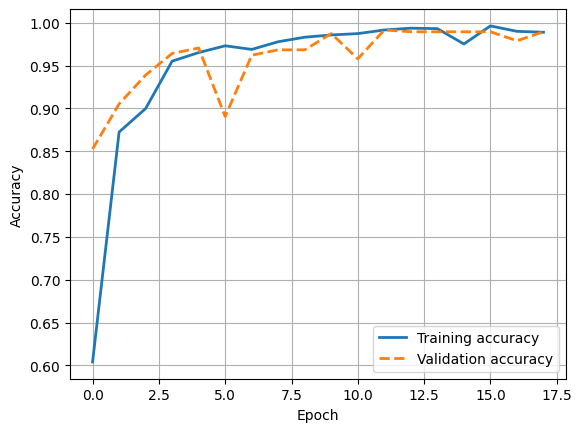

In [ ]:
plt.plot(history.history['accuracy'], linewidth=2)
plt.plot(history.history['val_accuracy'], linewidth=2, linestyle='dashed')
#plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Training accuracy', 'Validation accuracy'])
plt.grid(True)
plt.show()


Saving History as CSV file

In [ ]:
import pandas as pd

# Extract values from history.history
epochs = list(range(1, len(history.history['accuracy']) + 1))  # Epoch numbers
training_accuracy = history.history['accuracy']
validation_accuracy = history.history['val_accuracy']

# Create a DataFrame
df = pd.DataFrame({
    'Epoch': epochs,
    'Training Accuracy': training_accuracy,
    'Validation Accuracy': validation_accuracy
})

# Save to CSV file
df.to_csv('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/training_accuracy_PMBC.csv', index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


Checking CSV

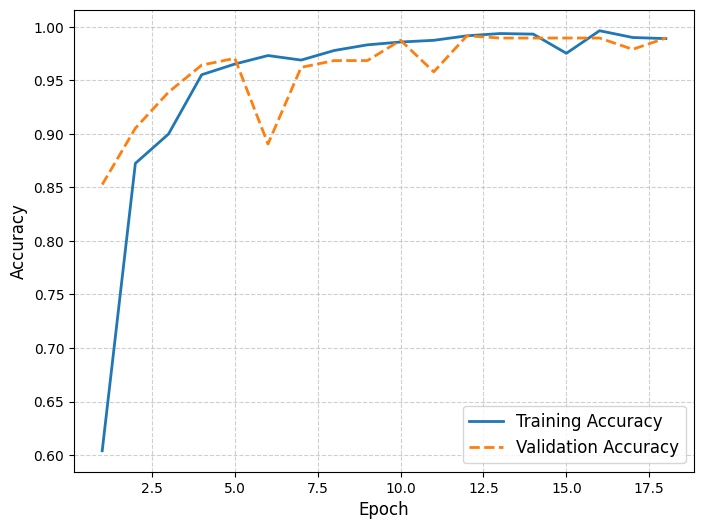

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV file
df = pd.read_csv('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/training_accuracy_PMBC.csv')

# Extract data
epochs = df["Epoch"]
training_accuracy = df["Training Accuracy"]
validation_accuracy = df["Validation Accuracy"]

# Create the plot
plt.figure(figsize=(8, 6))
plt.plot(epochs, training_accuracy, linewidth=2, label="Training Accuracy")
plt.plot(epochs, validation_accuracy, linewidth=2, linestyle='dashed', label="Validation Accuracy")

# Labels and legend
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Accuracy", fontsize=12)
plt.legend(fontsize=12, loc="lower right")
plt.grid(True, linestyle='--', alpha=0.6)

# Show the plot
plt.show()


CNN Loss Plot

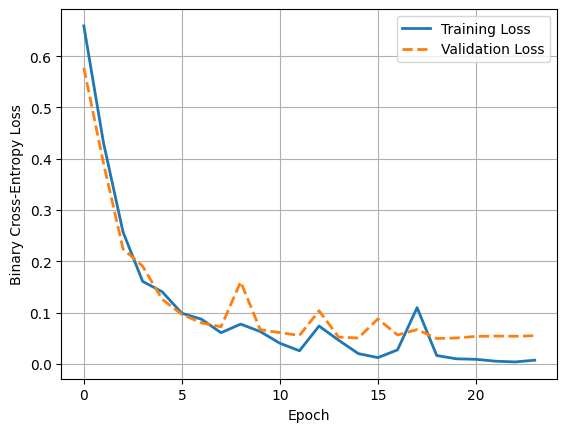

In [ ]:
# Plot CNN Training and Validation Loss
#plt.figure(figsize=(6, 4))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='dashed')

# Labels and title
#plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)

# Show plot
plt.show()

In [ ]:
import pandas as pd

# Extract values from history.history
epochs = list(range(1, len(history.history['loss']) + 1))  # Epoch numbers
training_loss = history.history['loss']
validation_loss = history.history['val_loss']

# Create a DataFrame
df = pd.DataFrame({
    'Epoch': epochs,
    'Training Loss': training_loss,
    'Validation Loss': validation_loss
})

# Save to CSV file
df.to_csv('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/training_loss_PMBC.csv', index=False)

print("CSV file saved successfully!")


CSV file saved successfully!


Classifier predicting on the real data

In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, roc_curve, auc
#classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier.h5')
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier_use_this_best.h5')
predictions = classifier.predict(data)
predicted_labels = (predictions > 0.5).astype(int)

cm = confusion_matrix(y, predicted_labels)

accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step
Confusion Matrix:
[[1184    2]
 [   4 1182]]
Accuracy: 0.9974704890387859
Precision: 0.9983108108108109
Recall: 0.9966273187183811
F1 Score: 0.9974683544303797


Confusion matrix plot for real image classification

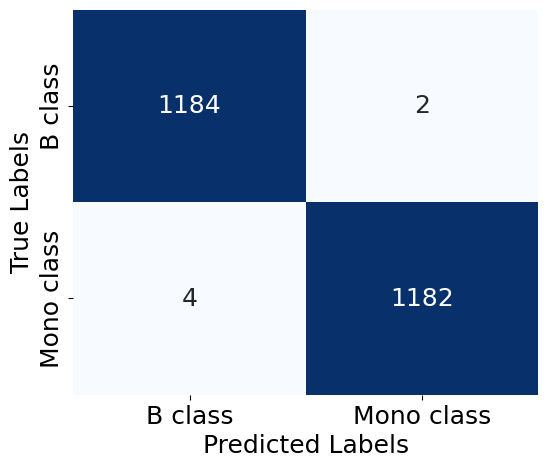

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define font sizes
label_fontsize = 18  # Font size for x and y labels
tick_fontsize = 18   # Font size for tick labels
annot_fontsize = 18  # Font size for the numbers inside the heatmap

plt.figure(figsize=(6, 5))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['B class', 'Mono class'],
            yticklabels=['B class', 'Mono class'],
            annot_kws={"size": annot_fontsize})  # Control font size of numbers

plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.show()


75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step
Confusion Matrix:
[[1184    2]
 [   4 1182]]
Accuracy: 0.9975
Precision: 0.9983
Recall: 0.9966
F1 Score: 0.9975


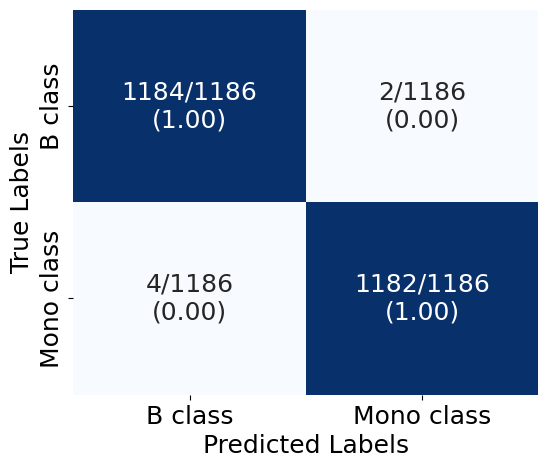

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

# Load the trained classifier
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier.h5')

# Make predictions
predictions = classifier.predict(data)
predicted_labels = (predictions > 0.5).astype(int)

# Compute confusion matrix and metrics
cm = confusion_matrix(y, predicted_labels)
accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

# Print results
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Normalize the confusion matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Format labels with count and percentage
labels = np.array([[f"{cm[i, j]}/{cm.sum(axis=1)[i]}\n({cm_normalized[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

# Define font sizes
label_fontsize = 18  # Font size for labels
tick_fontsize = 18   # Font size for tick labels
annot_fontsize = 18  # Font size for heatmap annotations

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=['B class', 'Mono class'],
            yticklabels=['B class', 'Mono class'],
            annot_kws={"size": annot_fontsize})  # Custom annotation size

# Set labels and ticks
plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Display the plot
plt.show()


Generating images

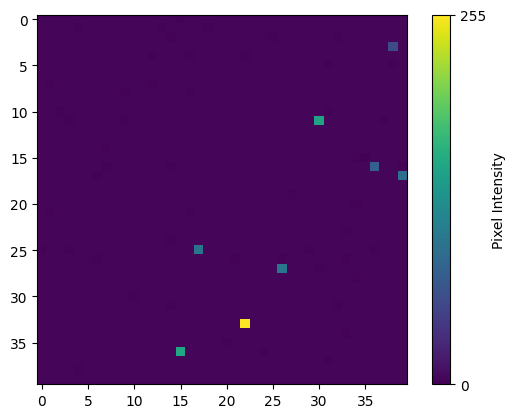

In [ ]:

# image = low_synthetic_data[10]

image = low_data[100]

fake_images = (image - np.min(image))/(np.max(image) - np.min(image))

fake_images *= 255.0

converted_images = fake_images.astype(np.uint8)


img = plt.imshow(converted_images, cmap='viridis',vmin=0, vmax=255)
cbar = plt.colorbar(img)
cbar.set_label('Pixel Intensity')
cbar.set_ticks([0, 255])  # Set the ticks at the min and max values
cbar.set_ticklabels(['0', '255'])

plt.imsave('/content/drive/MyDrive/GenoMap/image.png', converted_images, cmap='viridis')
plt.show()

Synthetic images evaluation

#b = low; mono = high


In [ ]:
low_synthetic_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/synthetic_b.npy')
high_synthetic_data = np.load('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/synthetic_mono.npy')
classifier = tf.keras.models.load_model('/content/drive/MyDrive/Ahsan/8. 2025 cGAN Hamid with Dr. Darren Dataset/classifier.h5')

In [ ]:
data = np.vstack([low_data, high_data ])
data = data.astype(np.float32)
#data = np.clip(data , -5 ,5)

_MIN = data.min()
_MAX = data.max()

data = -1 + 2*(data - _MIN)/(_MAX - _MIN)

print(_MAX)
print(_MIN)

34.409313
-2.4649649


In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score, roc_curve, auc

synthetic_data = np.vstack([low_synthetic_data, high_synthetic_data])
y = [0] * low_synthetic_data.shape[0] +  [1] * high_synthetic_data.shape[0]

synthetic_data = ((synthetic_data + 1) * (_MAX - _MIN) / 2) + _MIN  # Reverse normalization

predictions = classifier.predict(synthetic_data)

predicted_labels = (predictions > 0.5).astype(np.float32)

cm = confusion_matrix(y, predicted_labels)
accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

print("Confusion Matrix:")
print(cm)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
Confusion Matrix:
[[ 929  257]
 [  84 1102]]
Accuracy: 0.856239460370995
Precision: 0.8108903605592347
Recall: 0.9291736930860034
F1 Score: 0.8660117878192535


Plotting confusion matrix

b = low; mono = high

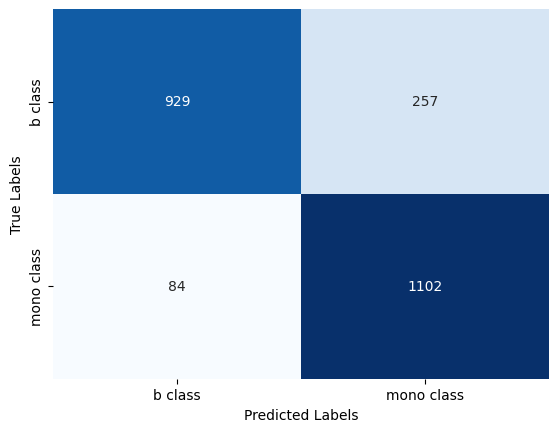

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns




sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
             xticklabels=['b class', 'mono class'],
             yticklabels=['b class', 'mono class'])

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

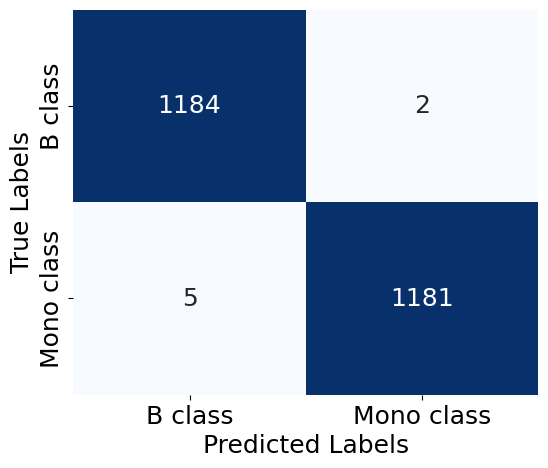

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define font sizes
label_fontsize = 18  # Font size for x and y labels
tick_fontsize = 18   # Font size for tick labels
annot_fontsize = 18  # Font size for the numbers inside the heatmap

plt.figure(figsize=(6, 5))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['B class', 'Mono class'],
            yticklabels=['B class', 'Mono class'],
            annot_kws={"size": annot_fontsize})  # Control font size of numbers

plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.show()


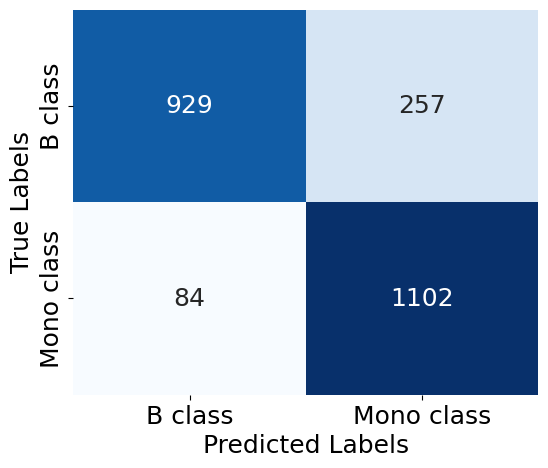

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define font sizes
label_fontsize = 18  # Font size for x and y labels
tick_fontsize = 18   # Font size for tick labels
annot_fontsize = 18  # Font size for the numbers inside the heatmap

plt.figure(figsize=(6, 5))  # Adjust figure size if needed
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=['B class', 'Mono class'],
            yticklabels=['B class', 'Mono class'],
            annot_kws={"size": annot_fontsize})  # Control font size of numbers

plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

plt.show()

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step
Confusion Matrix:
[[ 908  278]
 [  65 1121]]
Accuracy: 0.8554
Precision: 0.8013
Recall: 0.9452
F1 Score: 0.8673


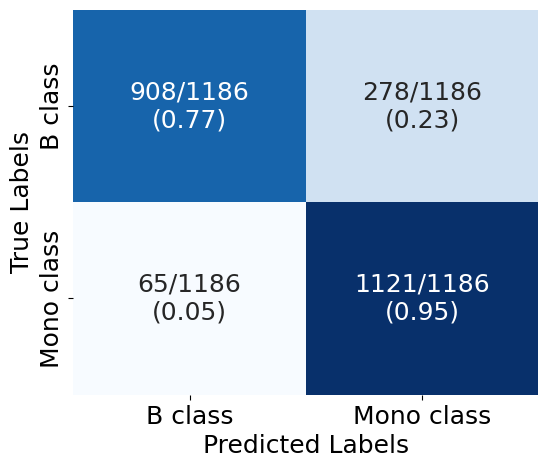

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, recall_score

# Stack synthetic data and create labels
synthetic_data = np.vstack([low_synthetic_data, high_synthetic_data])
y = [0] * low_synthetic_data.shape[0] + [1] * high_synthetic_data.shape[0]

# Reverse normalization
synthetic_data = ((synthetic_data + 1) * (_MAX - _MIN) / 2) + _MIN

# Make predictions
predictions = classifier.predict(synthetic_data)
predicted_labels = (predictions > 0.5).astype(np.float32)

# Compute confusion matrix and metrics
cm = confusion_matrix(y, predicted_labels)
accuracy = accuracy_score(y, predicted_labels)
precision = precision_score(y, predicted_labels)
recall = recall_score(y, predicted_labels)
f1 = f1_score(y, predicted_labels)

# Print results
print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# Normalize the confusion matrix (row-wise)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Format labels with count and percentage
labels = np.array([[f"{cm[i, j]}/{cm.sum(axis=1)[i]}\n({cm_normalized[i, j]:.2f})" for j in range(cm.shape[1])] for i in range(cm.shape[0])])

# Define font sizes
label_fontsize = 18  # Font size for labels
tick_fontsize = 18   # Font size for tick labels
annot_fontsize = 18  # Font size for heatmap annotations

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm_normalized, annot=labels, fmt="", cmap="Blues", cbar=False,
            xticklabels=['B class', 'Mono class'],
            yticklabels=['B class', 'Mono class'],
            annot_kws={"size": annot_fontsize})  # Custom annotation size

# Set labels and ticks
plt.xlabel("Predicted Labels", fontsize=label_fontsize)
plt.ylabel("True Labels", fontsize=label_fontsize)
plt.xticks(fontsize=tick_fontsize)
plt.yticks(fontsize=tick_fontsize)

# Display the plot
plt.show()


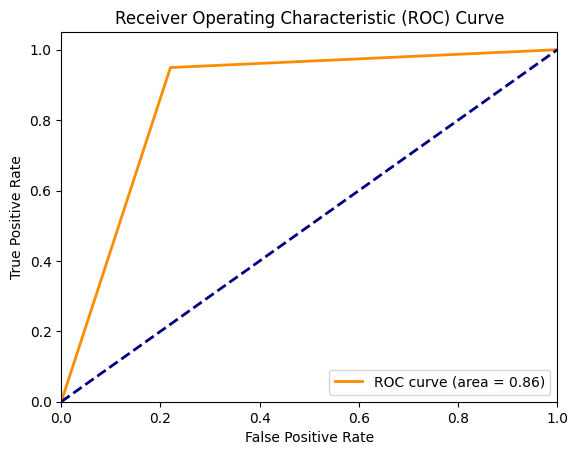

In [ ]:
# roc curve
fpr, tpr, thresholds = roc_curve(y, predicted_labels)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()